# **Exploratory Data Analysis**

This notebook explores the cleaned e-commerce dataset to understand distributions, detect outliers, examine relationships between variables, and extract initial business insights that will guide further analysis and feature engineering.

In [31]:
import pandas as pd
import numpy as np
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns
import math

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.2f}'.format)

In [32]:
# Load the cleaned dataset
eda_df = pd.read_csv('dataset/cleaned/ecommerce_cleaned.csv', parse_dates=['order_date'])

## Data Overview

In [33]:
eda_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000123 entries, 0 to 1000122
Data columns (total 33 columns):
 #   Column                  Non-Null Count    Dtype         
---  ------                  --------------    -----         
 0   order_date              1000123 non-null  datetime64[ns]
 1   order_year              1000123 non-null  int64         
 2   order_month             1000123 non-null  int64         
 3   is_weekend              1000123 non-null  object        
 4   customer_name           1000123 non-null  object        
 5   gender                  1000123 non-null  object        
 6   age                     1000123 non-null  int64         
 7   customer_segment        1000123 non-null  object        
 8   country                 1000123 non-null  object        
 9   order_status            1000123 non-null  object        
 10  category                1000123 non-null  object        
 11  sub_category            1000123 non-null  object        
 12  unit_price_usd

In [34]:
# Missing values (%)
print(((eda_df.isnull().sum() / len(eda_df)) * 100).to_string())

order_date               0.00
order_year               0.00
order_month              0.00
is_weekend               0.00
customer_name            0.00
gender                   0.00
age                      0.00
customer_segment         0.00
country                  0.00
order_status             0.00
category                 0.00
sub_category             0.00
unit_price_usd           0.00
quantity                 0.00
discount_percent         0.00
revenue_usd              0.00
profit_usd               0.00
profit_margin_percent    0.00
payment_method           0.00
shipping_method          0.00
shipping_cost_usd        0.00
delivery_days            0.00
shipping_country         0.00
rating                   0.00
customer_loyalty_score   0.00
coupon_used              0.00
session_duration_min     0.00
pages_visited            0.00
abandoned_cart_before    0.00
fraud_risk_score         0.00
device_type              0.00
campaign_source          0.00
traffic_source           0.00


In [35]:
eda_df.columns

Index(['order_date', 'order_year', 'order_month', 'is_weekend',
       'customer_name', 'gender', 'age', 'customer_segment', 'country',
       'order_status', 'category', 'sub_category', 'unit_price_usd',
       'quantity', 'discount_percent', 'revenue_usd', 'profit_usd',
       'profit_margin_percent', 'payment_method', 'shipping_method',
       'shipping_cost_usd', 'delivery_days', 'shipping_country', 'rating',
       'customer_loyalty_score', 'coupon_used', 'session_duration_min',
       'pages_visited', 'abandoned_cart_before', 'fraud_risk_score',
       'device_type', 'campaign_source', 'traffic_source'],
      dtype='object')

In [36]:
eda_df.sample(5)

,order_date,order_year,order_month,is_weekend,customer_name,gender,age,customer_segment,country,order_status,category,sub_category,unit_price_usd,quantity,discount_percent,revenue_usd,profit_usd,profit_margin_percent,payment_method,shipping_method,shipping_cost_usd,delivery_days,shipping_country,rating,customer_loyalty_score,coupon_used,session_duration_min,pages_visited,abandoned_cart_before,fraud_risk_score,device_type,campaign_source,traffic_source
282680,2024-08-13 16:42:54.844971,2024,8,No,Heather Snyder,Female,19,Regular,Canada,Completed,Electronics,Laptops,18.79,3,0,56.37,28.62,50.77,PayPal,Economy,14.46,7,Canada,4,99.60,No,5.50,15,Yes,8.00,Tablet,Email,Direct
418416,2025-12-03 05:28:55.180824,2025,12,No,Jeffrey Evans,Male,20,VIP,United States,Completed,Clothing,Accessories,61.81,3,10,166.89,38.73,23.21,Apple Pay,Next Day,1.01,12,United States,2,35.60,Yes,26.10,20,Yes,76.10,Mobile,Organic,Email
851199,2025-02-24 18:39:04.814987,2025,2,No,Ronald Johnson,Male,37,Regular,Spain,Completed,Health,Fitness,58.10,3,25,130.72,21.91,16.76,PayPal,Next Day,22.67,4,Spain,5,37.60,Yes,55.10,7,Yes,96.40,Desktop,Affiliate,Search
863759,2025-02-02 04:19:22.889985,2025,2,Yes,Brittany Melton,Female,39,Regular,Australia,Completed,Sports,Accessories,166.83,5,15,709.03,173.63,24.49,PayPal,Next Day,19.75,9,Australia,4,89.50,No,42.40,5,No,10.90,Desktop,Email,Referral
424625,2024-05-03 05:50:34.234661,2024,5,No,Daniel Oliver,Male,59,Regular,France,Completed,Home,Furniture,94.56,4,0,378.24,142.56,37.69,Bank Transfer,Economy,4.50,9,France,2,36.50,Yes,7.50,4,Yes,46.30,Tablet,Affiliate,Referral


## 2. Variable Classification

Columns were grouped by type so the appropriate analysis and visualization techniques could be applied.

In [37]:
categorical_cols = [
    'gender',
    'customer_segment',
    'category',
    'payment_method',
    'shipping_method',
    'device_type',
    'campaign_source',
    'traffic_source',
    'coupon_used',
    'abandoned_cart_before',
    'is_weekend',
    'order_status'
]

discrete_cols = [
    'quantity',
    'rating',
    'delivery_days',
    'discount_percent',
    'pages_visited',
    'order_month'
]

continuous_cols = [
    'unit_price_usd',
    'revenue_usd',
    'profit_usd',
    'profit_margin_percent',
    'shipping_cost_usd',
    'session_duration_min',
    'fraud_risk_score',
    'customer_loyalty_score'
]

## 3. Univariate Analysis

### 3.1 Categorical Variables

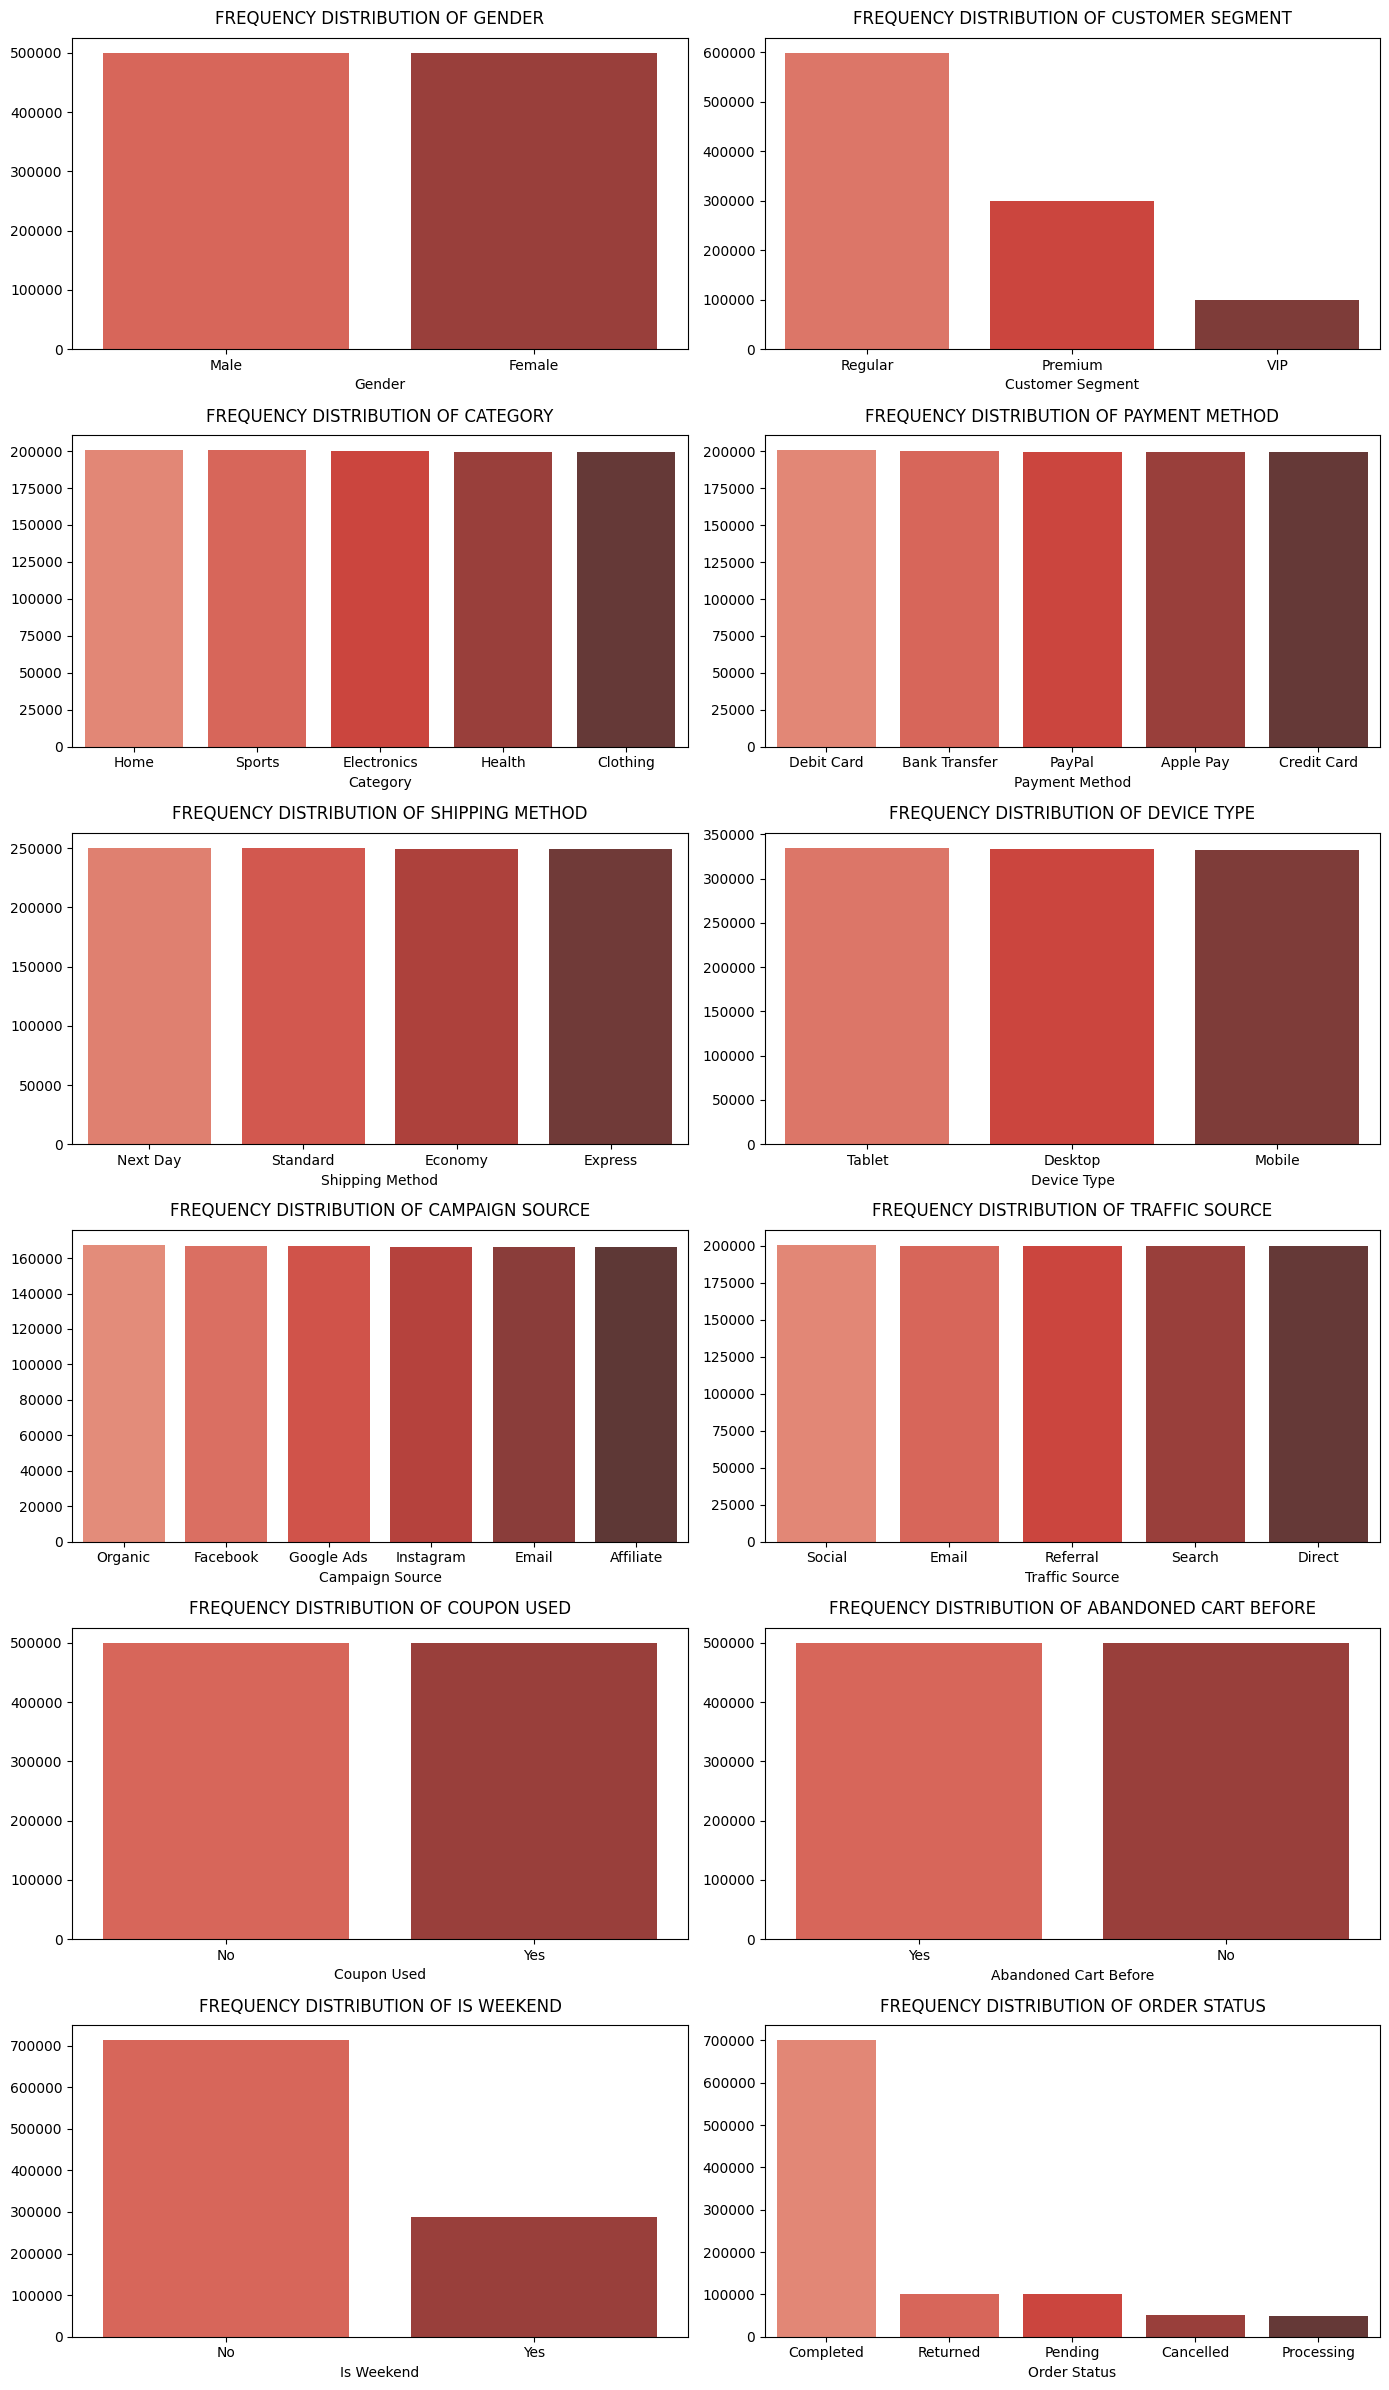

In [38]:
# Bar Graph of Categorical Variables
n_cols = 2
n_rows = math.ceil(len(categorical_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows))
axes = axes.flatten()  


for i, cons in enumerate(categorical_cols):
    ax = axes[i]
    count_plot = eda_df[cons].value_counts().sort_values(ascending=False)
    
    sns.barplot(
        x=count_plot.index,
        y=count_plot.values,
        ax=ax,
        color='steelblue',
        palette='Reds_d',
        legend=False,
        hue=count_plot.index,
    )
    
    # Title & labels
    title = f'Frequency Distribution of {cons.replace("_", " ")}'.upper()
    xlabel = cons.replace('_', ' ').title().replace('Usd', 'USD')
    
    ax.set_title(title, fontsize=12, pad=10)
    ax.set_xlabel(xlabel)

# Hide empty subplots if not exact multiple of 2
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

### 3.2 Discrete Variables

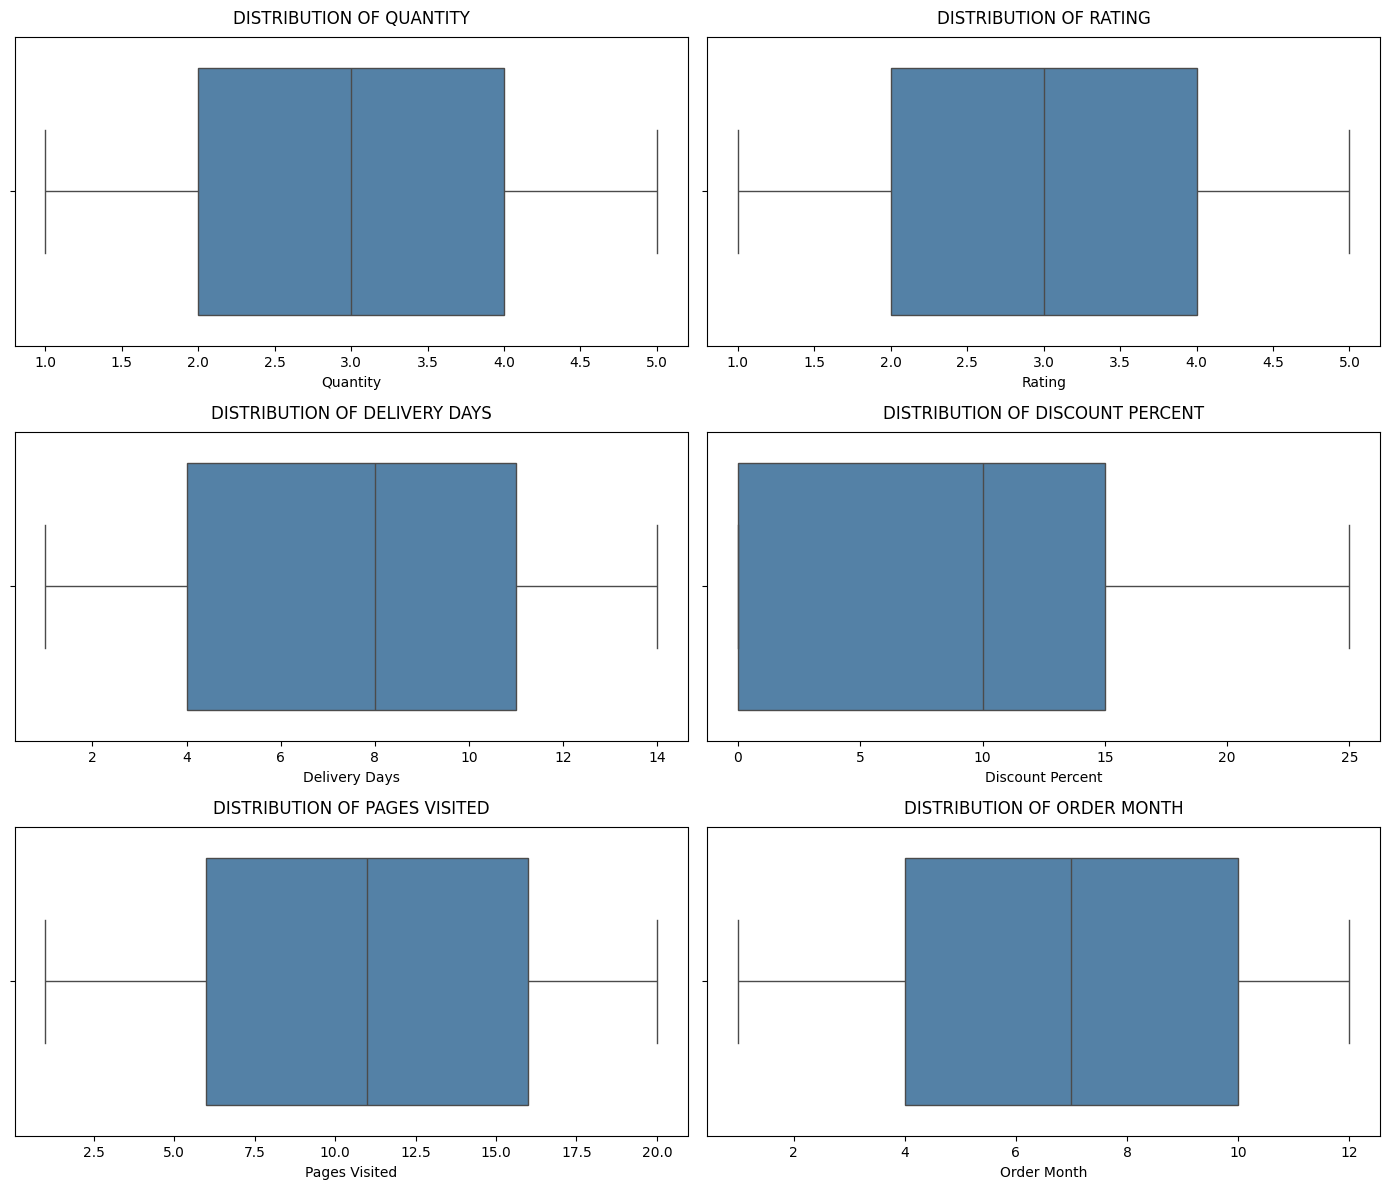

In [39]:
# Boxplot Distribution of Discrete Variables
n_cols = 2
n_rows = math.ceil(len(discrete_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows))
axes = axes.flatten()  
for i, cons in enumerate(discrete_cols):
    ax = axes[i]
    
    sns.boxplot(
        data=eda_df,
        x=cons,
        ax=ax,
        color='steelblue'
    )
    
    # Title & labels
    title = f'Distribution of {cons.replace("_", " ")}'.upper()
    xlabel = cons.replace('_', ' ').title().replace('Usd', 'USD')
    
    ax.set_title(title, fontsize=12, pad=10)
    ax.set_xlabel(xlabel)

# Hide empty subplots if not exact multiple of 2
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

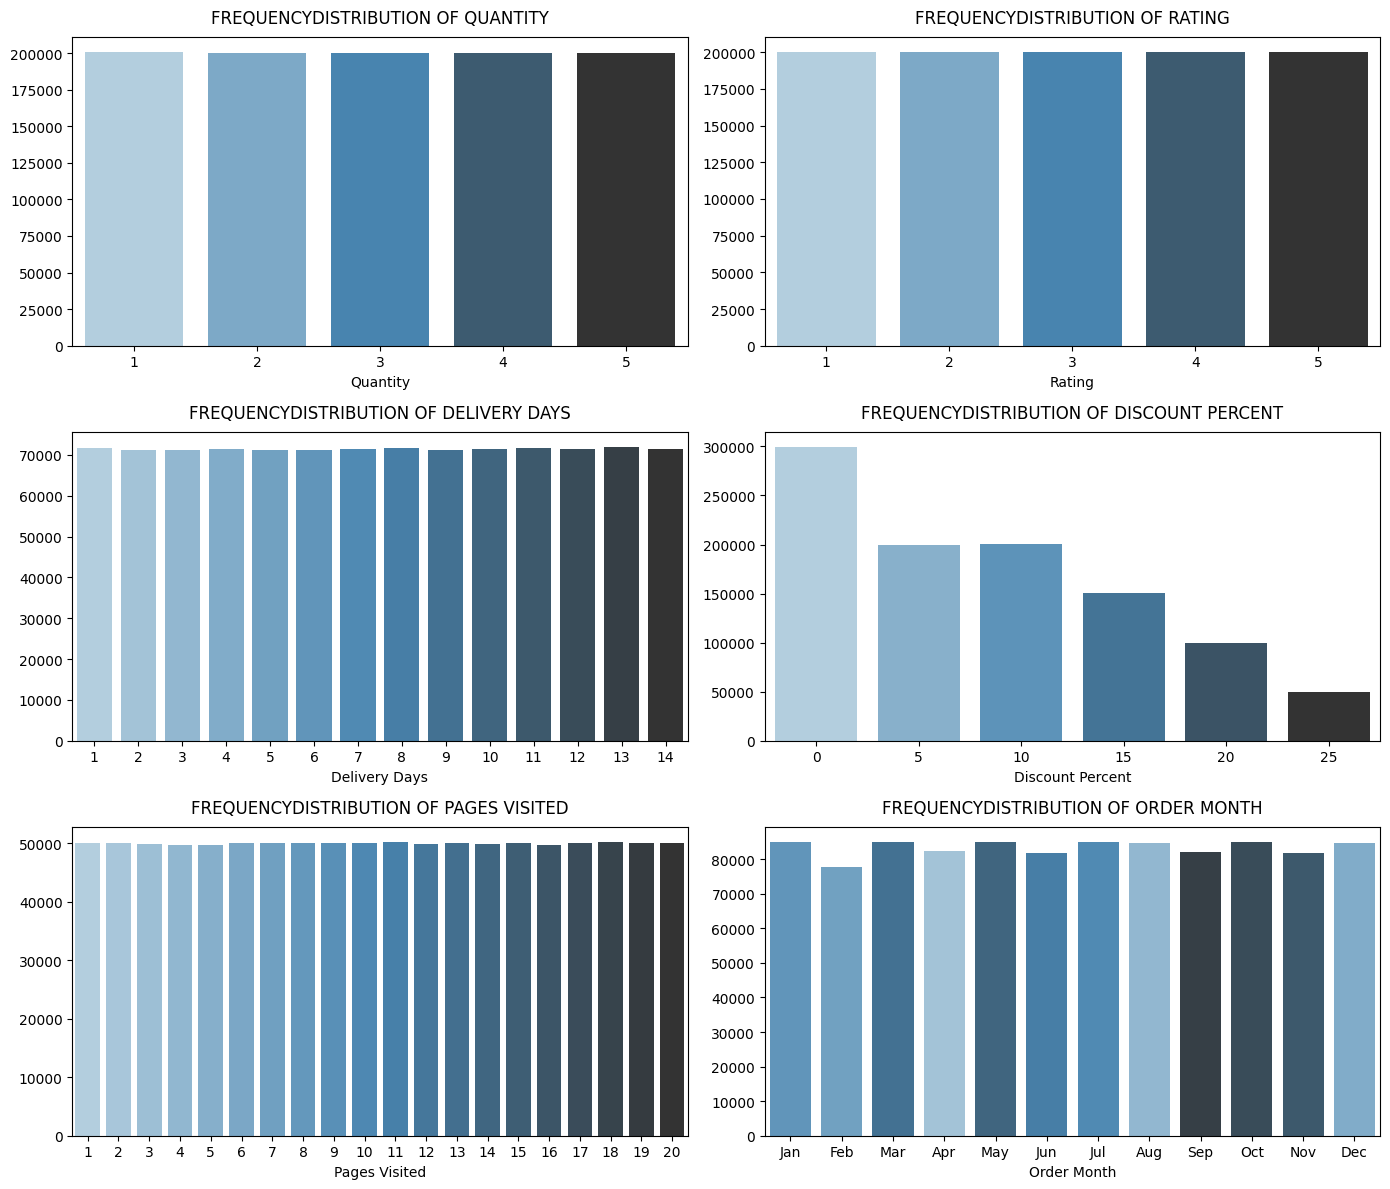

In [40]:
# Bar Graph of Discrete Variables
n_cols = 2
n_rows = math.ceil(len(discrete_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows))
axes = axes.flatten()  

# Custom order for column that has natural sequence
month_map = {
    1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr', 5: 'May', 6: 'Jun',
    7: 'Jul', 8: 'Aug', 9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dec'
}

eda_df['order_month'] = eda_df['order_month'].map(month_map)

# Then use this custom_order
custom_order = {
    'order_month': ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                    'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
}

for i, cons in enumerate(discrete_cols):
    ax = axes[i]
    count_plot = eda_df[cons].value_counts().sort_index()
    
    order = custom_order.get(cons, count_plot.index)
    
    sns.barplot(
        x=count_plot.index,
        y=count_plot.values,
        ax=ax,
        color='steelblue',
        palette='Blues_d',
        legend=False,
        hue=count_plot.index,
        order=order
    )
    
    # Title & labels
    title = f'FrequencyDistribution of {cons.replace("_", " ")}'.upper()
    xlabel = cons.replace('_', ' ').title().replace('Usd', 'USD')
    
    ax.set_title(title, fontsize=12, pad=10)
    ax.set_xlabel(xlabel)

# Hide empty subplots if not exact multiple of 2
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

### 3.3 Continuous Variables

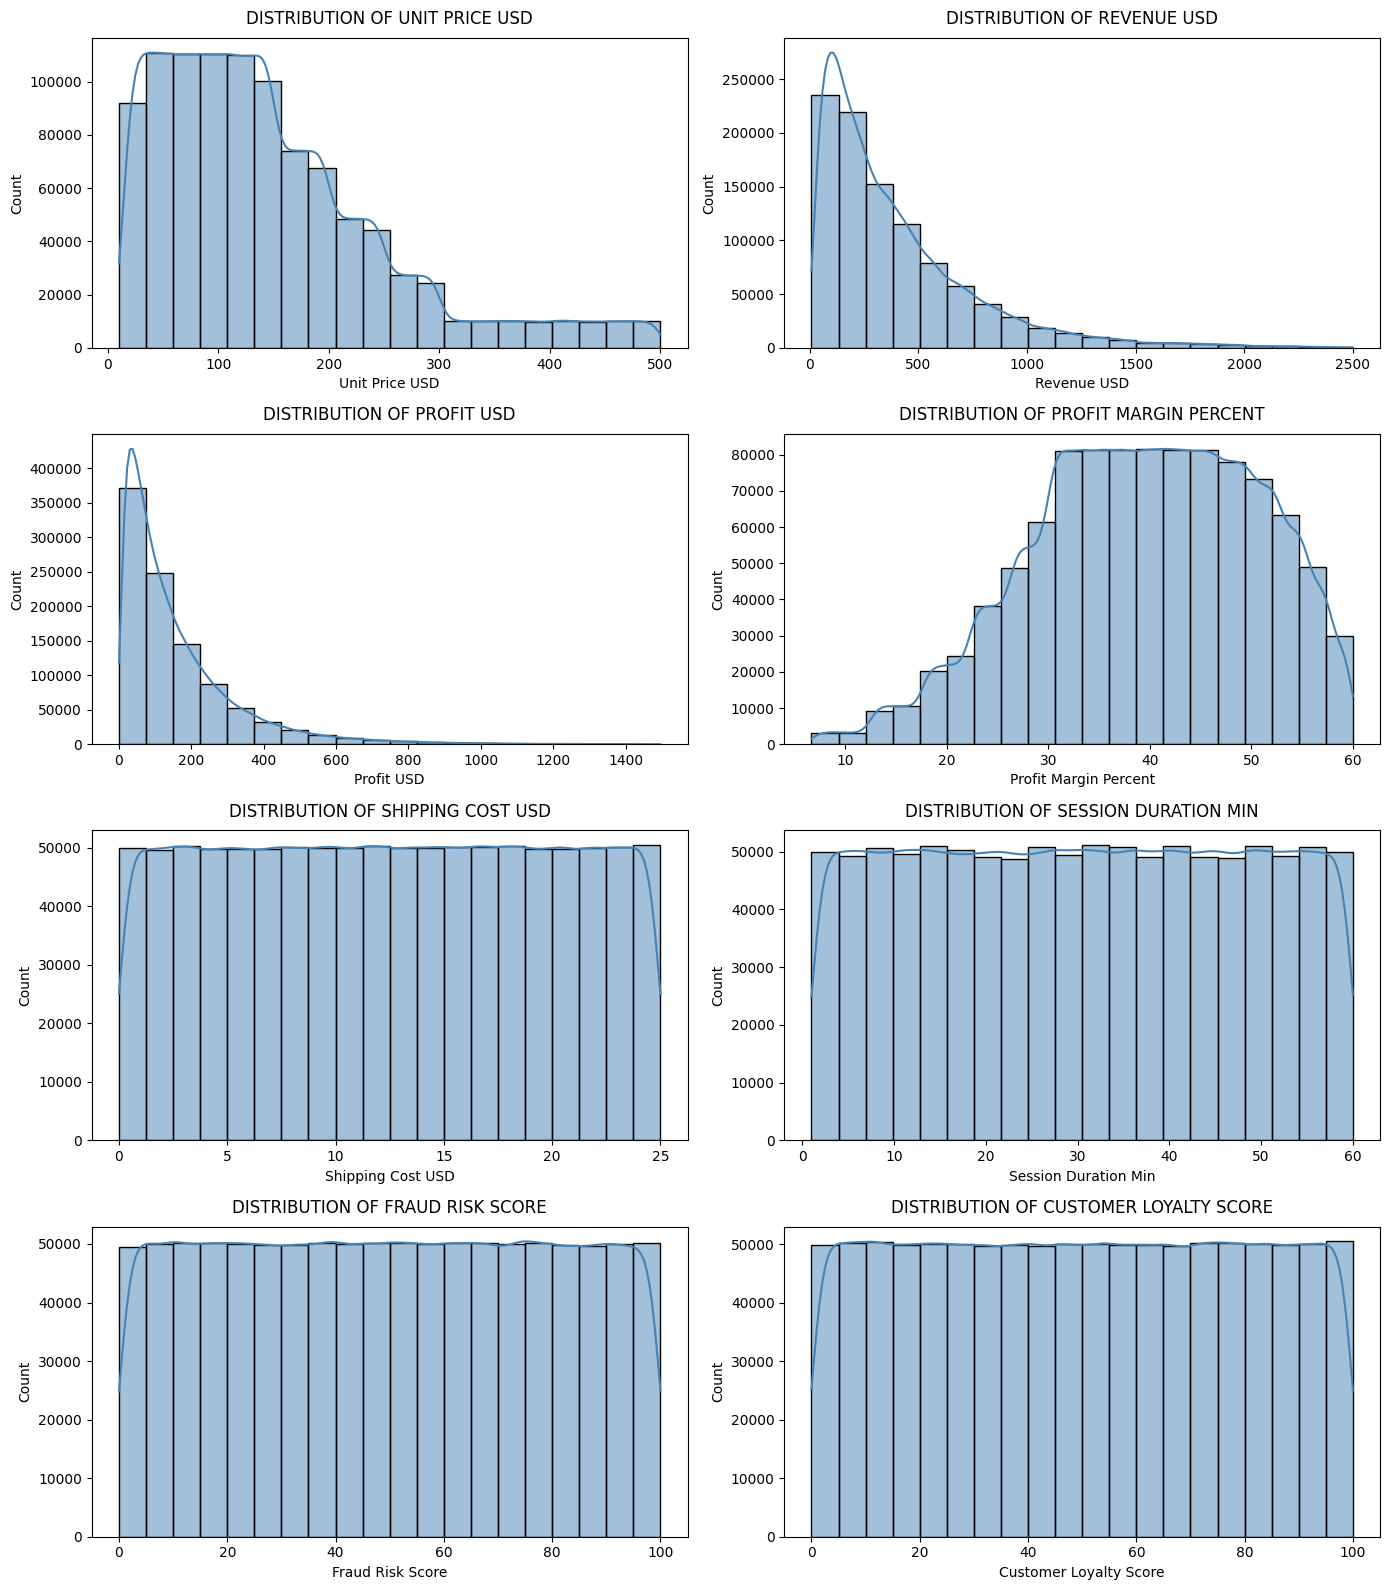

In [41]:
# Histogram Distribution of Continuous Variables

n_cols = 2
n_rows = math.ceil(len(continuous_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows))
axes = axes.flatten()  
for i, cons in enumerate(continuous_cols):
    ax = axes[i]
    
    sns.histplot(
        data=eda_df,
        x=cons,
        bins=20,
        ax=ax,
        color='steelblue',
        kde=True
    )
    
    # Title & labels
    title = f'Distribution of {cons.replace("_", " ")}'.upper()
    xlabel = cons.replace('_', ' ').title().replace('Usd', 'USD')
    
    ax.set_title(title, fontsize=12, pad=10)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Count')

# Hide empty subplots if not exact multiple of 2
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

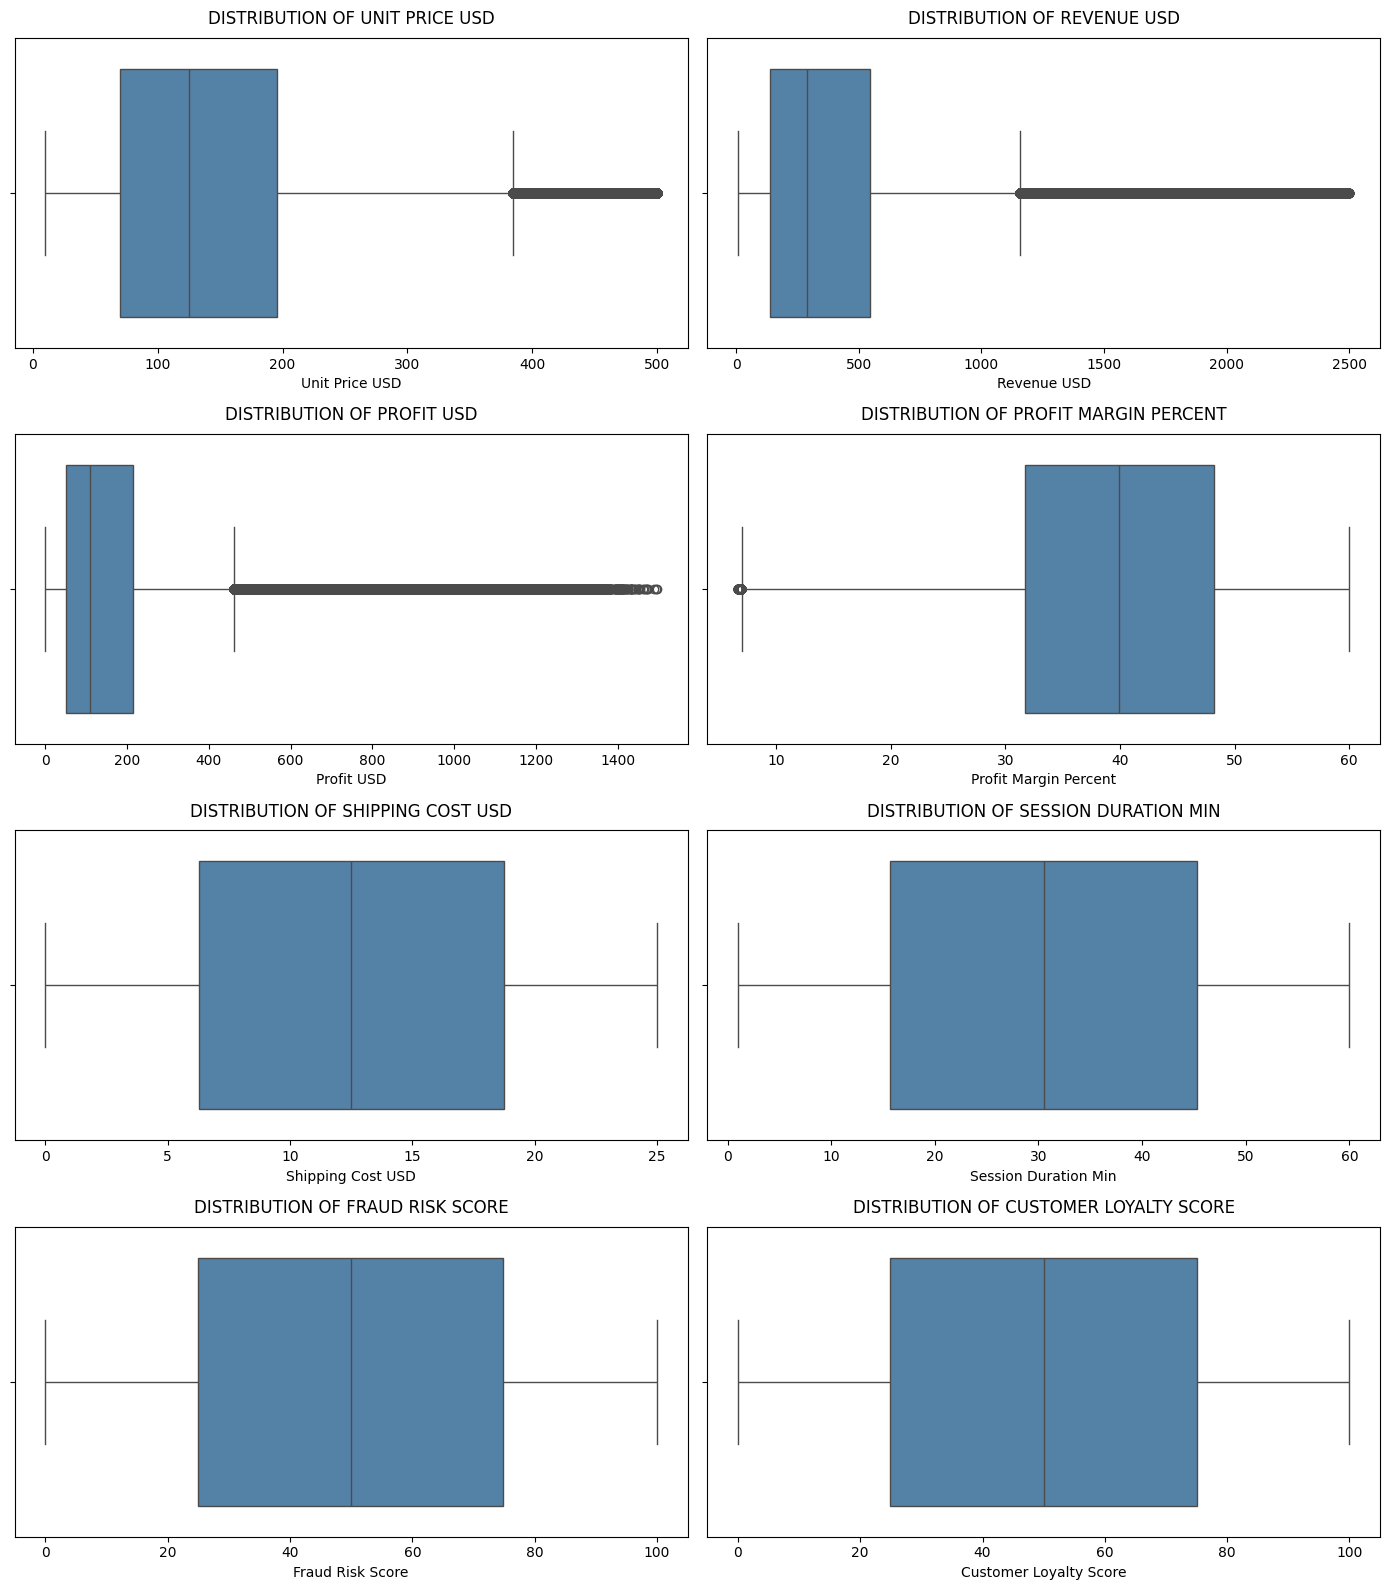

In [42]:
# Boxplot Distribution of Continuous Variables
n_cols = 2
n_rows = math.ceil(len(continuous_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows))
axes = axes.flatten()  
for i, cons in enumerate(continuous_cols):
    ax = axes[i]
    
    sns.boxplot(
        data=eda_df,
        x=cons,
        ax=ax,
        color='steelblue'
    )
    
    # Title & labels
    title = f'Distribution of {cons.replace("_", " ")}'.upper()
    xlabel = cons.replace('_', ' ').title().replace('Usd', 'USD')
    
    ax.set_title(title, fontsize=12, pad=10)
    ax.set_xlabel(xlabel)

# Hide empty subplots if not exact multiple of 2
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

The histograms, boxplots, and bar charts provided a comprehensive understanding of the distributions of the continuous, discrete, and categorical variables.

## 4. Outlier Detection using IQR

The Interquartile Range (IQR) method was applied only to continuous variables to identify potential outliers.

In [43]:
# Detect outliers in continuous columns using the IQR rule

outlier_summary = []

for col in continuous_cols:
    Q1 = eda_df[col].quantile(0.25)
    Q3 = eda_df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = eda_df[(eda_df[col] < lower) | (eda_df[col] > upper)]
    count = len(outliers)
    percent = (count / len(eda_df)) * 100

    if percent > 0:
        outlier_summary.append({
            'Column': col,
            'Outliers': count,
            'Percentage (%)': round(percent, 2)
        })

outlier_df = pd.DataFrame(outlier_summary)
outlier_df

,Column,Outliers,Percentage (%)
0,unit_price_usd,47098,4.71
1,revenue_usd,49298,4.93
2,profit_usd,56873,5.69
3,profit_margin_percent,352,0.04


Based on the IQR method applied to continuous variables, four columns were identified as containing potential outliers: **`unit_price_usd`**, **`revenue_usd`**, **`profit_usd`**, and **`profit_margin_percent`**.

- `unit_price_usd` (4.71%), `revenue_usd` (4.93%), and `profit_usd` (5.69%) show approximately 5% outliers.
- `profit_margin_percent` contains only 0.04% outliers.

---

> Although the IQR method flagged potential outliers in several continuous features, the earlier histograms and boxplots indicate that these observations are consistent with the underlying data distribution rather than being apparent anomalies. Since the identified values likely represent legitimate business transactions and natural variability, **no outlier treatment was applied**.

## 5. Correlation Analysis

### 5.1 Correlation Heatmap
Pearson correlation across numeric variables.

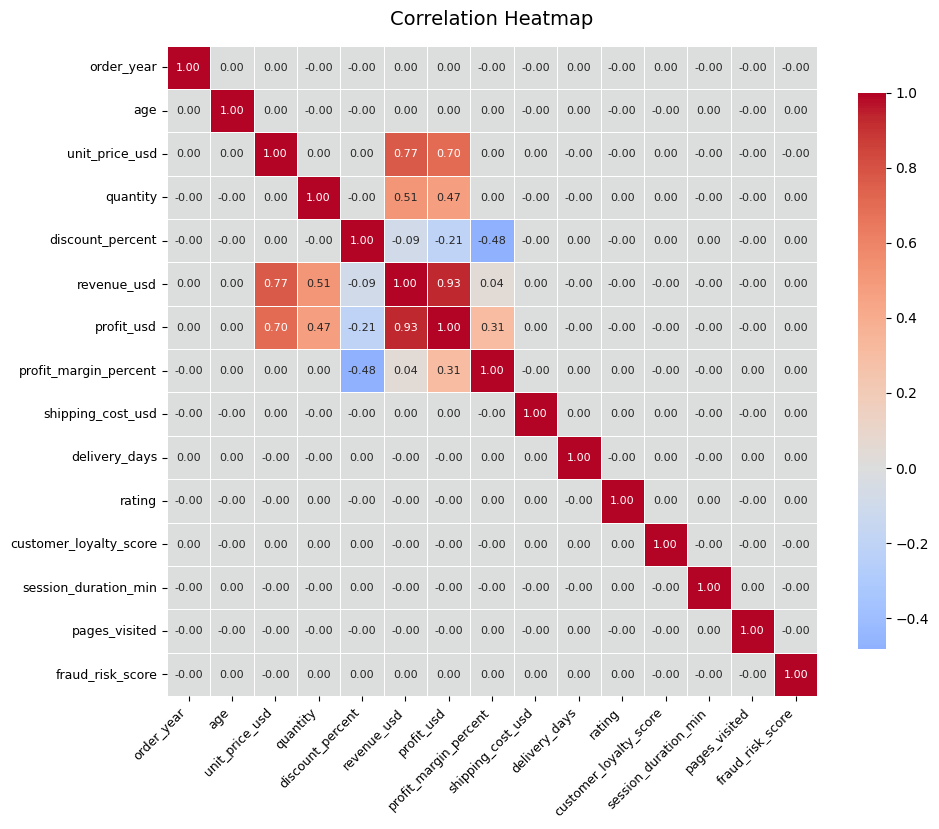

In [44]:
# Heatmap of Correlation Matrix

n = len(eda_df.select_dtypes(include='number').columns)
fig_size = max(10, n * 0.6)         

plt.figure(figsize=(fig_size, fig_size * 0.85))

sns.heatmap(
    data=eda_df.select_dtypes(include='number').corr(),
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8},
    annot_kws={"size": 8}
)

plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.title('Correlation Heatmap', fontsize=14, pad=15)

plt.tight_layout()
plt.show()

### 5.2 Pairplot of Key Variables

Pairplot of variables that showed meaningful positive or negative correlations in the heatmap, focusing on the main financial drivers.

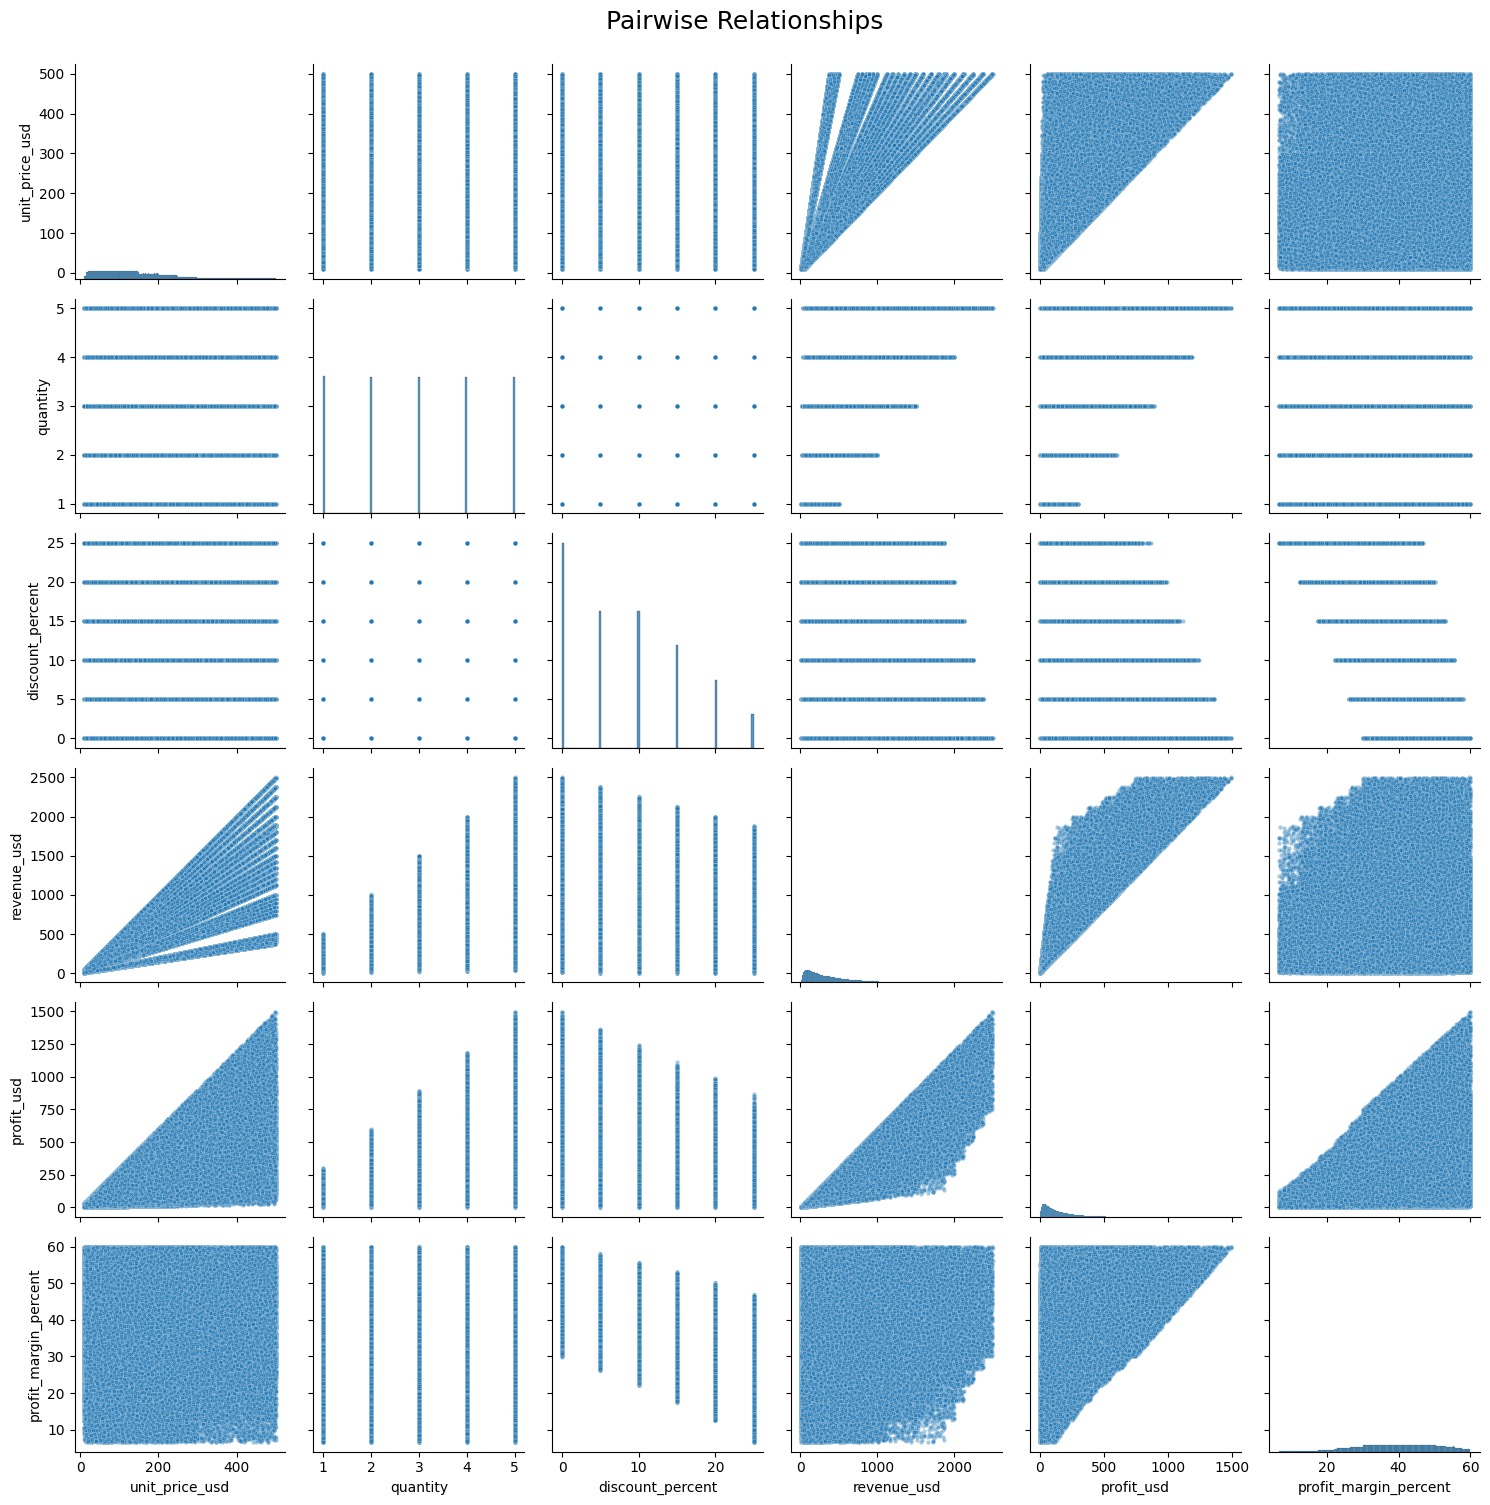

In [45]:
# Pairwise Relationships

selected_cols = [
    'unit_price_usd',
    'quantity',
    'discount_percent',
    'revenue_usd',
    'profit_usd',
    'profit_margin_percent'
]

g = sns.pairplot(
    eda_df[selected_cols],
    diag_kind='hist',
    plot_kws={'alpha': 0.4, 's': 10},
)

g.fig.suptitle('Pairwise Relationships', fontsize=18, y=1)

plt.tight_layout()
plt.show()

## 6. Summary of Initial Insights

- Revenue and profit are primarily driven by **unit price** and **quantity**.
- `unit_price_usd` and `quantity` themselves show **little linear relationship**.
- Discounts have a moderate negative effect on **profit margin** without a clear increase in purchase volume.
- Most customer behavior and operational variables (age, rating, loyalty, session duration, fraud risk, etc.) show **near-zero linear correlation with financial outcomes**.
- Flagged outliers in continuous variables appear consistent with natural right-skewed business distributions; no outlier treatment was applied.
- These findings will guide feature engineering and domain-specific analyses (sales, customers, marketing, and logistics).